In [9]:
import pandas as pd

# --- Load the cleaned and transformed dataset ---
df = pd.read_csv("cleaned_data_transformed.csv")
df.head()

,realSum,logSum,room_type_apt,room_type_private,room_type_shared,person_capacity,is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,city,is_weekday
0,194.033698,5.268032,0,1,0,2.0,0,1,0,10.0,93.0,1,5.022964,2.539380,78.690379,4.166708,98.253896,6.846473,1,1
1,344.245776,5.841356,0,1,0,4.0,0,0,0,8.0,85.0,1,0.488389,0.239404,631.176378,33.421209,837.280757,58.342928,1,1
2,264.101422,5.576333,0,1,0,2.0,0,0,1,9.0,87.0,1,5.748312,3.651621,75.275877,3.985908,95.386955,6.646700,1,1
3,433.529398,6.071960,0,1,0,4.0,0,0,1,9.0,90.0,2,0.384862,0.439876,493.272534,26.119108,875.033098,60.973565,1,1
4,485.552926,6.185288,0,1,0,2.0,1,0,0,10.0,98.0,1,0.544738,0.318693,552.830324,29.272733,815.305740,56.811677,1,1


                            OLS Regression Results                            
Dep. Variable:                 logSum   R-squared:                       0.421
Model:                            OLS   Adj. R-squared:                  0.421
Method:                 Least Squares   F-statistic:                     2661.
Date:                Mon, 11 May 2026   Prob (F-statistic):               0.00
Time:                        14:26:04   Log-Likelihood:                -28979.
No. Observations:               51189   AIC:                         5.799e+04
Df Residuals:                   51174   BIC:                         5.812e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

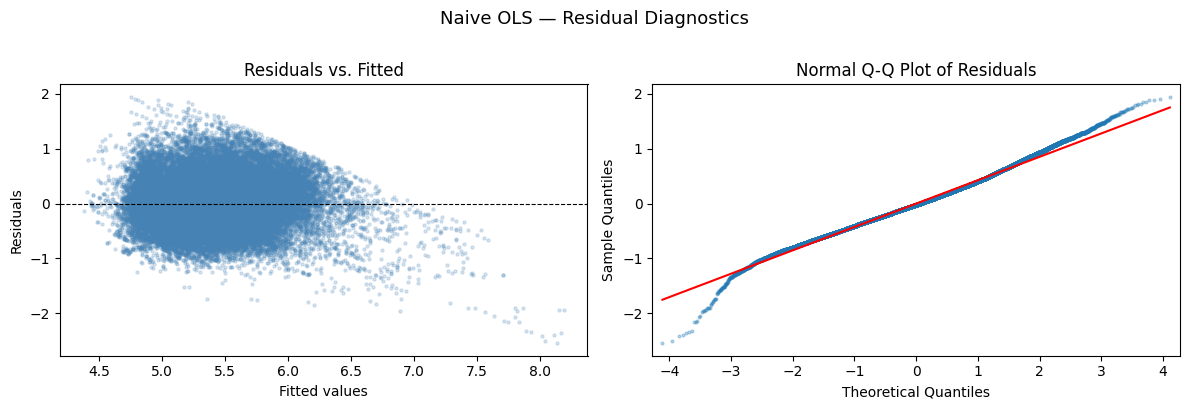

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- Part 2: Naive Multiple Linear Regression Baseline ---
# Target : logSum
# Features: all numeric + dummies, normalized attraction/restaurant indices,
#           city excluded, attr_index / rest_index (non-normalized) excluded
#
# Dummy variable treatment: room_type has 3 levels (apt, private, shared).
# Including all 3 with an intercept causes perfect multicollinearity (dummy trap).
# Drop room_type_shared as the reference category; coefficients for
# room_type_apt and room_type_private are interpreted relative to shared rooms.

feature_cols = [
    "room_type_apt", "room_type_private",   # room_type_shared = reference
    "person_capacity", "is_superhost", "multi", "biz",
    "cleanliness_rating", "guest_satisfaction_overall",
    "bedrooms", "dist", "metro_dist",
    "attr_index_norm", "rest_index_norm",
    "is_weekday",
]

X = df[feature_cols].copy()
y = df["logSum"]

X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())

# --- VIF to quantify multicollinearity ---
vif_data = {
    "Feature": feature_cols,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
}
import pandas as pd
vif_df = (
    pd.DataFrame(vif_data)
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)
print("\nVariance Inflation Factors:")
print(vif_df.to_string(index=False))
print(f"\nNaive OLS RMSE: {np.sqrt(model.mse_resid):.4f}")

# --- Residual diagnostics ---
fitted = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(fitted, residuals, alpha=0.2, s=5, color="steelblue")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs. Fitted")

sm.qqplot(residuals, line="s", ax=axes[1], alpha=0.3, markersize=2)
axes[1].set_title("Normal Q-Q Plot of Residuals")

plt.suptitle("Naive OLS — Residual Diagnostics", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("naive_ols_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()


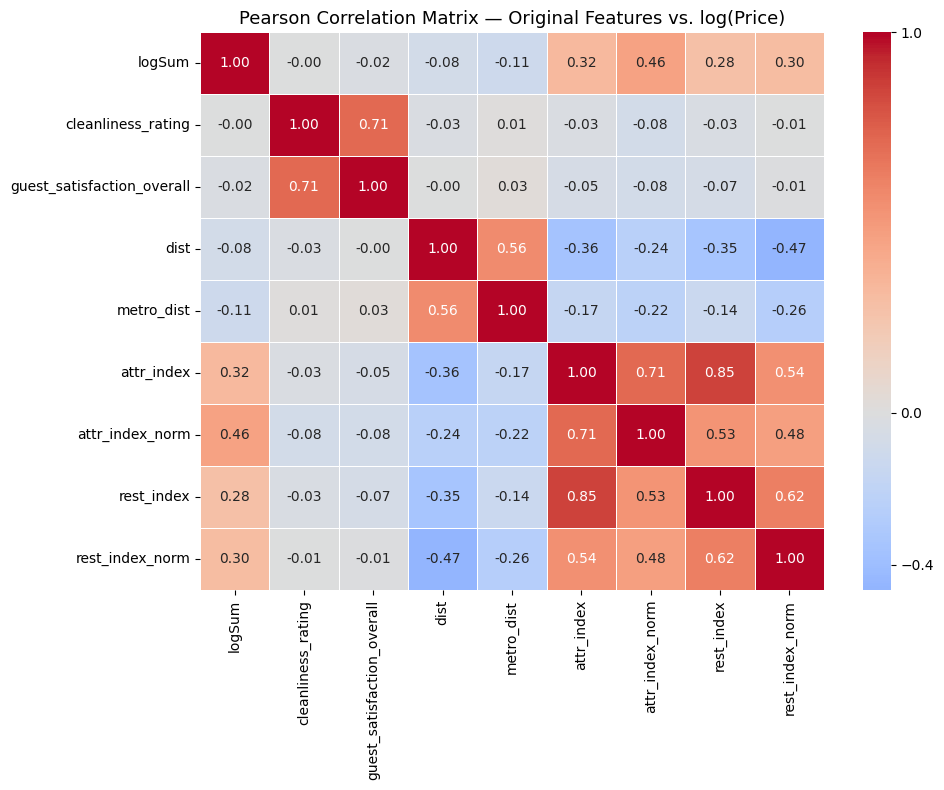

                              logSum
logSum                      1.000000
attr_index_norm             0.455700
attr_index                  0.319955
rest_index_norm             0.297390
rest_index                  0.279247
cleanliness_rating         -0.004160
guest_satisfaction_overall -0.022962
dist                       -0.081282
metro_dist                 -0.107059


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Part 1: Correlation Matrix — Original Features ---

corr_cols_orig = [
    "logSum",
    "cleanliness_rating", "guest_satisfaction_overall",
    "dist", "metro_dist",
    "attr_index", "attr_index_norm",
    "rest_index", "rest_index_norm",
]

corr_matrix_orig = df[corr_cols_orig].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix_orig,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"ticks": [1.0, 0.0, -0.4]},
)
ax.set_title("Pearson Correlation Matrix — Original Features vs. log(Price)", fontsize=13)
plt.tight_layout()
plt.savefig("correlation_matrix_original.png", dpi=300, bbox_inches="tight")
plt.show()

print(corr_matrix_orig[["logSum"]].sort_values("logSum", ascending=False).to_string())


                            OLS Regression Results                            
Dep. Variable:                 logSum   R-squared:                       0.420
Model:                            OLS   Adj. R-squared:                  0.420
Method:                 Least Squares   F-statistic:                     3084.
Date:                Mon, 11 May 2026   Prob (F-statistic):               0.00
Time:                        14:26:05   Log-Likelihood:                -29050.
No. Observations:               51189   AIC:                         5.813e+04
Df Residuals:                   51176   BIC:                         5.824e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 3.9286      0.02

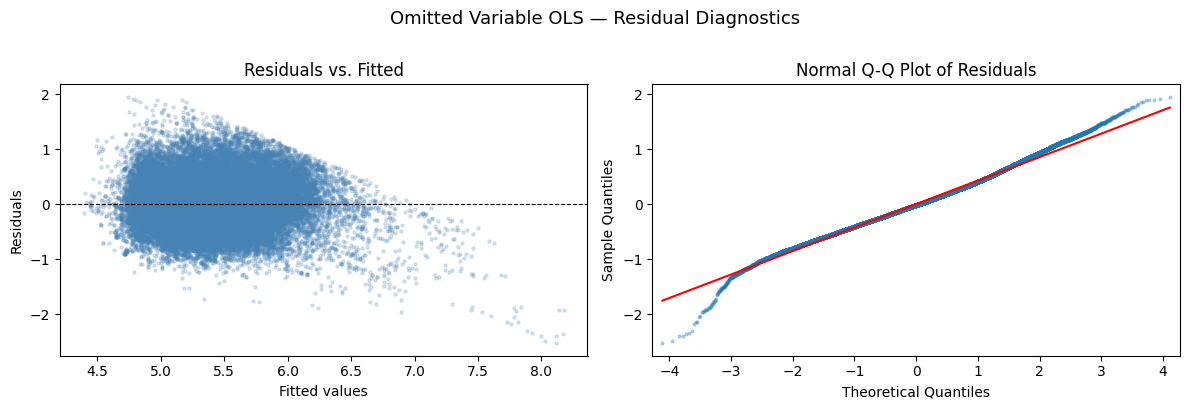


=== MODEL COMPARISON ===
Metric                       Naive OLS   Omitted OLS
----------------------------------------------------
R²                              0.4213        0.4197
Adj. R²                         0.4211        0.4196
RMSE                            0.4263        0.4269
AIC                           57987.59      58126.09
BIC                           58120.24      58241.05
F-statistic                    2661.08       3084.23
# predictors                        14            12


In [12]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# --- Part 4: Omitted Variable OLS ---
# Satisfaction and cleanliness variables (cleanliness_rating,
# guest_satisfaction_overall, satisfaction_pc1, satisfaction_pc2) are dropped entirely.
# All other specifications unchanged from the naive baseline.

feature_cols_omitted = [
    "room_type_apt", "room_type_private",   # room_type_shared = reference
    "person_capacity", "is_superhost", "multi", "biz",
    "bedrooms", "dist", "metro_dist",
    "attr_index_norm", "rest_index_norm",
    "is_weekday",
]

X_om = df[feature_cols_omitted].copy()
y = df["logSum"]

X_om_const = sm.add_constant(X_om)
model_omitted = sm.OLS(y, X_om_const).fit()
print(model_omitted.summary())

# --- VIF ---
vif_om = pd.DataFrame({
    "Feature": feature_cols_omitted,
    "VIF": [variance_inflation_factor(X_om.values, i) for i in range(X_om.shape[1])],
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print("\nVariance Inflation Factors (Omitted Variable Model):")
print(vif_om.to_string(index=False))

# --- Residual diagnostics ---
fitted_om = model_omitted.fittedvalues
residuals_om = model_omitted.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(fitted_om, residuals_om, alpha=0.2, s=5, color="steelblue")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs. Fitted")

sm.qqplot(residuals_om, line="s", ax=axes[1], alpha=0.3, markersize=2)
axes[1].set_title("Normal Q-Q Plot of Residuals")

plt.suptitle("Omitted Variable OLS — Residual Diagnostics", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("omitted_ols_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Two-way model comparison: Naive vs Omitted ---
print("\n=== MODEL COMPARISON ===")
print(f"{'Metric':<25} {'Naive OLS':>12} {'Omitted OLS':>13}")
print("-" * 52)
print(f"{'R²':<25} {model.rsquared:>12.4f} {model_omitted.rsquared:>13.4f}")
print(f"{'Adj. R²':<25} {model.rsquared_adj:>12.4f} {model_omitted.rsquared_adj:>13.4f}")
print(f"{'RMSE':<25} {np.sqrt(model.mse_resid):>12.4f} {np.sqrt(model_omitted.mse_resid):>13.4f}")
print(f"{'AIC':<25} {model.aic:>12.2f} {model_omitted.aic:>13.2f}")
print(f"{'BIC':<25} {model.bic:>12.2f} {model_omitted.bic:>13.2f}")
print(f"{'F-statistic':<25} {model.fvalue:>12.2f} {model_omitted.fvalue:>13.2f}")
print(f"{'# predictors':<25} {len(feature_cols):>12d} {len(feature_cols_omitted):>13d}")


In [13]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Part 3: PCA Composite for Satisfaction (2 components) ---
# Motivation: the Naive OLS showed VIF ~195–207 for cleanliness_rating and
# guest_satisfaction_overall, and the Omitted OLS showed dropping them hurts fit.
# Solution: replace both with orthogonal PCA scores that retain all variance (VIF ≈ 1).

rating_cols = ["cleanliness_rating", "guest_satisfaction_overall"]
scaler = StandardScaler()
ratings_scaled = scaler.fit_transform(df[rating_cols])

pca_sat = PCA(n_components=2, random_state=42)
pc_scores = pca_sat.fit_transform(ratings_scaled)

print("Explained variance ratio per component:")
for i, evr in enumerate(pca_sat.explained_variance_ratio_, 1):
    print(f"  PC{i}: {evr:.3f}")
print(f"  Total: {pca_sat.explained_variance_ratio_.sum():.3f}")

print("\nLoadings:")
for i, comp in enumerate(pca_sat.components_, 1):
    print(f"  PC{i} — cleanliness_rating: {comp[0]:.3f}, "
          f"guest_satisfaction_overall: {comp[1]:.3f}")

# Insert satisfaction_pc1 and satisfaction_pc2 after guest_satisfaction_overall
insert_idx = df.columns.get_loc("guest_satisfaction_overall") + 1
df.insert(insert_idx,     "satisfaction_pc1", pc_scores[:, 0])
df.insert(insert_idx + 1, "satisfaction_pc2", pc_scores[:, 1])

print(f"\nColumns inserted at positions {insert_idx} and {insert_idx + 1}. df shape: {df.shape}")
df[["cleanliness_rating", "guest_satisfaction_overall", "satisfaction_pc1", "satisfaction_pc2"]].head()


Explained variance ratio per component:
  PC1: 0.856
  PC2: 0.144
  Total: 1.000

Loadings:
  PC1 — cleanliness_rating: 0.707, guest_satisfaction_overall: 0.707
  PC2 — cleanliness_rating: -0.707, guest_satisfaction_overall: 0.707

Columns inserted at positions 11 and 12. df shape: (51189, 22)


,cleanliness_rating,guest_satisfaction_overall,satisfaction_pc1,satisfaction_pc2
0,10.0,93.0,0.483801,-0.421538
1,8.0,85.0,-1.631521,0.428074
2,9.0,87.0,-0.732074,-0.154946
3,9.0,90.0,-0.494753,0.082375
4,10.0,98.0,0.879336,-0.026003


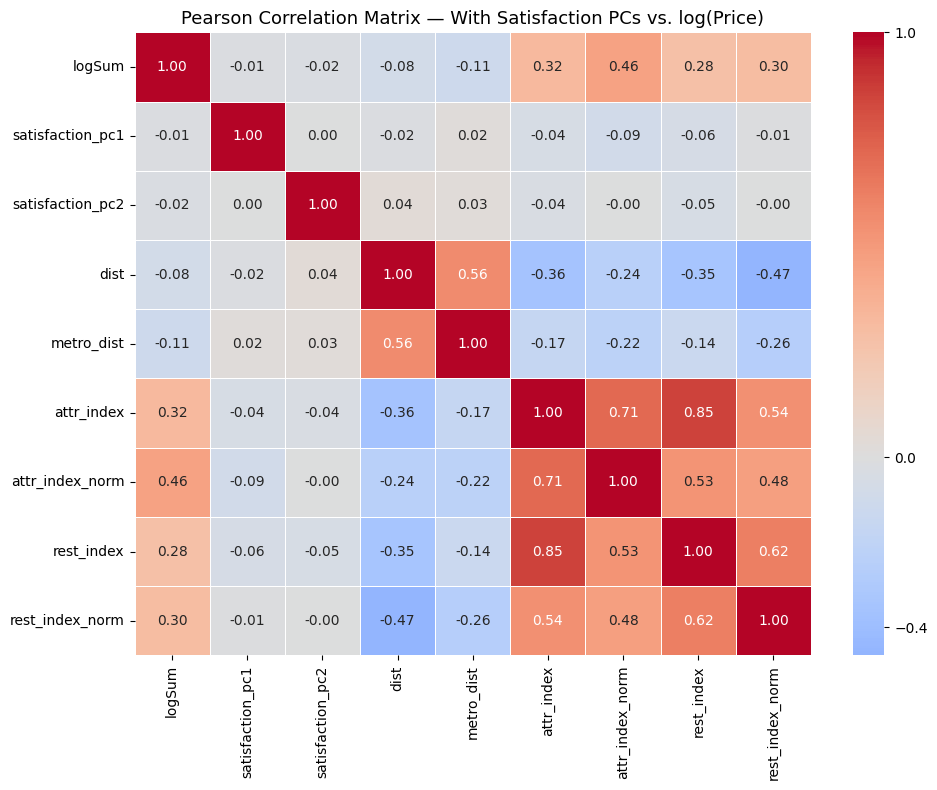

                    logSum
logSum            1.000000
attr_index_norm   0.455700
attr_index        0.319955
rest_index_norm   0.297390
rest_index        0.279247
satisfaction_pc1 -0.014654
satisfaction_pc2 -0.024800
dist             -0.081282
metro_dist       -0.107059


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Part 3 (continued): Correlation Matrix — After Satisfaction PCA (PC1 + PC2) ---
# cleanliness_rating + guest_satisfaction_overall replaced by satisfaction_pc1 + satisfaction_pc2

corr_cols = [
    "logSum",
    "satisfaction_pc1", "satisfaction_pc2",
    "dist", "metro_dist",
    "attr_index", "attr_index_norm",
    "rest_index", "rest_index_norm",
]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"ticks": [1.0, 0.0, -0.4]},
)
ax.set_title("Pearson Correlation Matrix — With Satisfaction PCs vs. log(Price)", fontsize=13)
plt.tight_layout()
plt.savefig("correlation_matrix_satisfaction_pca.png", dpi=300, bbox_inches="tight")
plt.show()

print(corr_matrix[["logSum"]].sort_values("logSum", ascending=False).to_string())


                            OLS Regression Results                            
Dep. Variable:                 logSum   R-squared:                       0.421
Model:                            OLS   Adj. R-squared:                  0.421
Method:                 Least Squares   F-statistic:                     2661.
Date:                Mon, 11 May 2026   Prob (F-statistic):               0.00
Time:                        14:26:06   Log-Likelihood:                -28979.
No. Observations:               51189   AIC:                         5.799e+04
Df Residuals:                   51174   BIC:                         5.812e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 3.9356      0.02

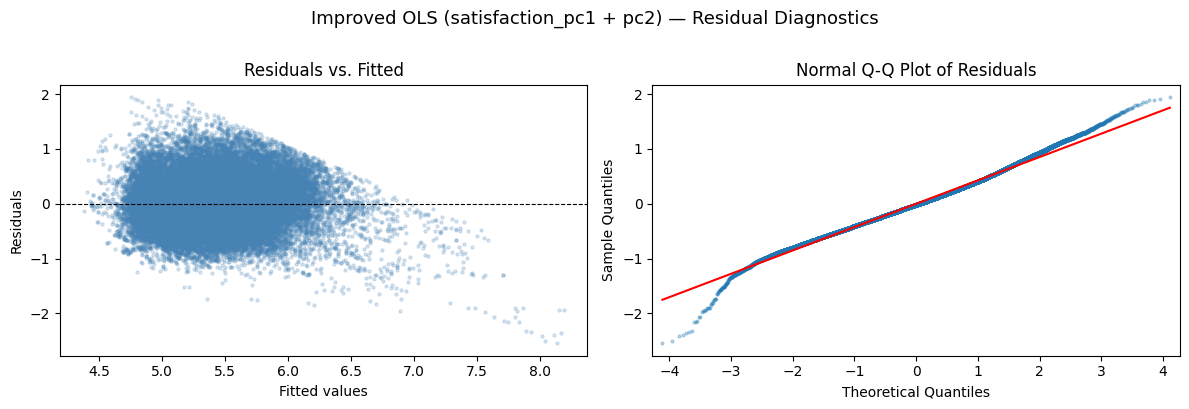


=== MODEL COMPARISON ===
Metric                       Naive OLS   Omitted OLS   Improved OLS
------------------------------------------------------------------
R²                              0.4213        0.4197         0.4213
Adj. R²                         0.4211        0.4196         0.4211
RMSE                            0.4263        0.4269         0.4263
AIC                           57987.59      58126.09       57987.59
BIC                           58120.24      58241.05       58120.24
F-statistic                    2661.08       3084.23        2661.08
# predictors                        14            12             14


In [15]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# --- Part 3: Improved Multiple Linear Regression ---
# satisfaction_pc1 + satisfaction_pc2 replace cleanliness_rating + guest_satisfaction_overall.
# Both PCs are orthogonal (VIF ≈ 1.0 between them), preserving all original variance
# while eliminating the collinearity that distorted the naive model.

feature_cols_improved = [
    "room_type_apt", "room_type_private",   # room_type_shared = reference
    "person_capacity", "is_superhost", "multi", "biz",
    "satisfaction_pc1", "satisfaction_pc2",
    "bedrooms", "dist", "metro_dist",
    "attr_index_norm", "rest_index_norm",
    "is_weekday",
]

X_imp = df[feature_cols_improved].copy()
y = df["logSum"]

X_imp_const = sm.add_constant(X_imp)
model_improved = sm.OLS(y, X_imp_const).fit()
print(model_improved.summary())

# --- VIF ---
vif_imp = pd.DataFrame({
    "Feature": feature_cols_improved,
    "VIF": [variance_inflation_factor(X_imp.values, i) for i in range(X_imp.shape[1])],
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print("\nVariance Inflation Factors (Improved Model):")
print(vif_imp.to_string(index=False))

# --- Residual diagnostics ---
fitted_imp = model_improved.fittedvalues
residuals_imp = model_improved.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(fitted_imp, residuals_imp, alpha=0.2, s=5, color="steelblue")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs. Fitted")

sm.qqplot(residuals_imp, line="s", ax=axes[1], alpha=0.3, markersize=2)
axes[1].set_title("Normal Q-Q Plot of Residuals")

plt.suptitle("Improved OLS (satisfaction_pc1 + pc2) — Residual Diagnostics", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("improved_ols_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Three-way model comparison: Naive, Omitted, Improved ---
print("\n=== MODEL COMPARISON ===")
print(f"{'Metric':<25} {'Naive OLS':>12} {'Omitted OLS':>13} {'Improved OLS':>14}")
print("-" * 66)
print(f"{'R²':<25} {model.rsquared:>12.4f} {model_omitted.rsquared:>13.4f} {model_improved.rsquared:>14.4f}")
print(f"{'Adj. R²':<25} {model.rsquared_adj:>12.4f} {model_omitted.rsquared_adj:>13.4f} {model_improved.rsquared_adj:>14.4f}")
print(f"{'RMSE':<25} {np.sqrt(model.mse_resid):>12.4f} {np.sqrt(model_omitted.mse_resid):>13.4f} {np.sqrt(model_improved.mse_resid):>14.4f}")
print(f"{'AIC':<25} {model.aic:>12.2f} {model_omitted.aic:>13.2f} {model_improved.aic:>14.2f}")
print(f"{'BIC':<25} {model.bic:>12.2f} {model_omitted.bic:>13.2f} {model_improved.bic:>14.2f}")
print(f"{'F-statistic':<25} {model.fvalue:>12.2f} {model_omitted.fvalue:>13.2f} {model_improved.fvalue:>14.2f}")
print(f"{'# predictors':<25} {len(feature_cols):>12d} {len(feature_cols_omitted):>13d} {len(feature_cols_improved):>14d}")


                            OLS Regression Results                            
Dep. Variable:                 logSum   R-squared:                       0.668
Model:                            OLS   Adj. R-squared:                  0.668
Method:                 Least Squares   F-statistic:                     4485.
Date:                Mon, 11 May 2026   Prob (F-statistic):               0.00
Time:                        14:26:06   Log-Likelihood:                -14722.
No. Observations:               51189   AIC:                         2.949e+04
Df Residuals:                   51165   BIC:                         2.970e+04
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 4.9125      0.02

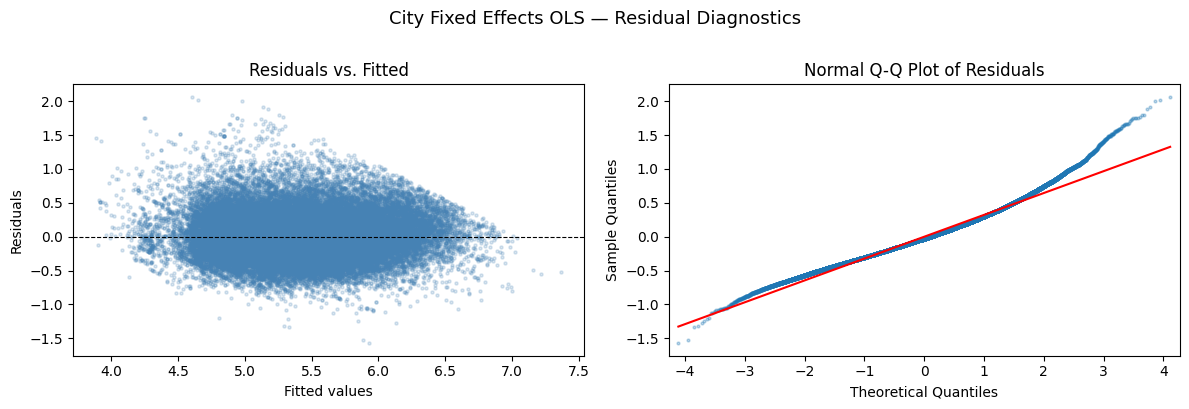


=== MODEL COMPARISON ===
Metric                      Naive OLS  Omitted OLS  Improved OLS  City FE OLS
---------------------------------------------------------------------------
R²                             0.4213       0.4197        0.4213       0.6685
Adj. R²                        0.4211       0.4196        0.4211       0.6683
RMSE                           0.4263       0.4269        0.4263       0.3227
AIC                          57987.59     58126.09      57987.59     29492.04
BIC                          58120.24     58241.05      58120.24     29704.28
F-statistic                   2661.08      3084.23       2661.08      4485.15
# predictors                       14           12            14           23


In [16]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# --- Part 5: City Fixed Effects OLS ---
# One-hot encode the city column (10 cities → 9 dummies).
# City 1 (Amsterdam) dropped as reference category.
# Original integer city column is retained in df; dummies are created on the fly.
# All other specifications identical to Improved OLS (satisfaction_pc1 + satisfaction_pc2).

city_dummies = pd.get_dummies(df["city"], prefix="city", drop_first=True).astype(int)
# city_2=Athens, city_3=Barcelona, ..., city_10=Vienna

feature_cols_city = (
    ["room_type_apt", "room_type_private"]   # room_type_shared = reference
    + ["person_capacity", "is_superhost", "multi", "biz"]
    + ["satisfaction_pc1", "satisfaction_pc2"]
    + ["bedrooms", "dist", "metro_dist"]
    + ["attr_index_norm", "rest_index_norm"]
    + ["is_weekday"]
    + list(city_dummies.columns)             # 9 city dummies
)

X_city = pd.concat([df[feature_cols_city[:-9]], city_dummies], axis=1)
y = df["logSum"]

X_city_const = sm.add_constant(X_city)
model_city = sm.OLS(y, X_city_const).fit()
print(model_city.summary())

# --- VIF ---
vif_city = pd.DataFrame({
    "Feature": feature_cols_city,
    "VIF": [variance_inflation_factor(X_city.values, i) for i in range(X_city.shape[1])],
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print("\nVariance Inflation Factors (City Fixed Effects Model):")
print(vif_city.to_string(index=False))

# --- Residual diagnostics ---
fitted_city = model_city.fittedvalues
residuals_city = model_city.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(fitted_city, residuals_city, alpha=0.2, s=5, color="steelblue")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs. Fitted")

sm.qqplot(residuals_city, line="s", ax=axes[1], alpha=0.3, markersize=2)
axes[1].set_title("Normal Q-Q Plot of Residuals")

plt.suptitle("City Fixed Effects OLS — Residual Diagnostics", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("city_fe_ols_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Four-way model comparison: Naive, Omitted, Improved, City FE ---
print("\n=== MODEL COMPARISON ===")
print(f"{'Metric':<25} {'Naive OLS':>11} {'Omitted OLS':>12} {'Improved OLS':>13} {'City FE OLS':>12}")
print("-" * 75)
print(f"{'R²':<25} {model.rsquared:>11.4f} {model_omitted.rsquared:>12.4f} {model_improved.rsquared:>13.4f} {model_city.rsquared:>12.4f}")
print(f"{'Adj. R²':<25} {model.rsquared_adj:>11.4f} {model_omitted.rsquared_adj:>12.4f} {model_improved.rsquared_adj:>13.4f} {model_city.rsquared_adj:>12.4f}")
print(f"{'RMSE':<25} {np.sqrt(model.mse_resid):>11.4f} {np.sqrt(model_omitted.mse_resid):>12.4f} {np.sqrt(model_improved.mse_resid):>13.4f} {np.sqrt(model_city.mse_resid):>12.4f}")
print(f"{'AIC':<25} {model.aic:>11.2f} {model_omitted.aic:>12.2f} {model_improved.aic:>13.2f} {model_city.aic:>12.2f}")
print(f"{'BIC':<25} {model.bic:>11.2f} {model_omitted.bic:>12.2f} {model_improved.bic:>13.2f} {model_city.bic:>12.2f}")
print(f"{'F-statistic':<25} {model.fvalue:>11.2f} {model_omitted.fvalue:>12.2f} {model_improved.fvalue:>13.2f} {model_city.fvalue:>12.2f}")
print(f"{'# predictors':<25} {len(feature_cols):>11d} {len(feature_cols_omitted):>12d} {len(feature_cols_improved):>13d} {len(feature_cols_city):>12d}")
